<a href="https://colab.research.google.com/github/AndrejHorvat1/Multibeam-Forward-Looking-Sonar/blob/main/UATD_SPLIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
from glob import glob

def split_image_and_labels(image_dir, label_dir, output_dir, subset):
    os.makedirs(f"{output_dir}/images/{subset}", exist_ok=True)
    os.makedirs(f"{output_dir}/labels/{subset}", exist_ok=True)

    image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        img_id = os.path.splitext(filename)[0]
        label_path = os.path.join(label_dir, f"{img_id}.txt")

        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        mid = w // 2

        left_img = img[:, :mid]
        right_img = img[:, mid:]

        with open(label_path, "r") as f:
            lines = [l.strip() for l in f if l.strip()]

        halves = [("left", left_img, 0, mid), ("right", right_img, mid, w)]
        for side, half_img, x_start, x_end in halves:
            new_boxes = []
            for line in lines:
                cls, x, y, bw, bh = map(float, line.split())

                abs_x = x * w
                abs_y = y * h
                abs_bw = bw * w
                abs_bh = bh * h

                x_min = abs_x - abs_bw / 2
                x_max = abs_x + abs_bw / 2

                # Preskoči bbox ako nije u ovoj polovici
                if x_max < x_start or x_min > x_end:
                    continue

                # Prilagodba granice i normalizizacija
                clipped_x_min = max(x_min, x_start)
                clipped_x_max = min(x_max, x_end)

                new_abs_x = (clipped_x_min + clipped_x_max) / 2 - x_start
                new_bw = clipped_x_max - clipped_x_min

                x_center = new_abs_x / mid
                y_center = abs_y / h
                norm_bw = new_bw / mid
                norm_bh = abs_bh / h

                new_boxes.append(f"{int(cls)} {x_center:.6f} {y_center:.6f} {norm_bw:.6f} {norm_bh:.6f}")

            if new_boxes:
                half_img_name = f"{img_id}_{side}.jpg"
                half_lbl_name = f"{img_id}_{side}.txt"

                cv2.imwrite(os.path.join(output_dir, "images", subset, half_img_name), half_img)
                with open(os.path.join(output_dir, "labels", subset, half_lbl_name), "w") as f:
                    f.write("\n".join(new_boxes))

                print(f"{subset}/{half_img_name} spremno.")


base_input = "/content/drive/MyDrive/UATD_YOLO_Dataset_v2"
output_split = "/content/drive/MyDrive/UATD_YOLO_Dataset_SPLIT"

split_image_and_labels(
    image_dir=os.path.join(base_input, "images/train"),
    label_dir=os.path.join(base_input, "labels/train"),
    output_dir=output_split,
    subset="train"
)

split_image_and_labels(
    image_dir=os.path.join(base_input, "images/val"),
    label_dir=os.path.join(base_input, "labels/val"),
    output_dir=output_split,
    subset="val"
)


Izlaz streaminga skraćen je na ovoliko posljednjih redaka: 5000.
train/07431_aug_right.jpg spremno.
train/07432_left.jpg spremno.
train/07432_right.jpg spremno.
train/07432_aug_left.jpg spremno.
train/07432_aug_right.jpg spremno.
train/07435_left.jpg spremno.
train/07435_right.jpg spremno.
train/07435_aug_left.jpg spremno.
train/07435_aug_right.jpg spremno.
train/07436_left.jpg spremno.
train/07436_aug_left.jpg spremno.
train/07437_left.jpg spremno.
train/07437_right.jpg spremno.
train/07437_aug_left.jpg spremno.
train/07437_aug_right.jpg spremno.
train/07438_left.jpg spremno.
train/07438_right.jpg spremno.
train/07438_aug_left.jpg spremno.
train/07438_aug_right.jpg spremno.
train/07441_left.jpg spremno.
train/07441_right.jpg spremno.
train/07441_aug_left.jpg spremno.
train/07441_aug_right.jpg spremno.
train/07442_left.jpg spremno.
train/07442_aug_left.jpg spremno.
train/07443_left.jpg spremno.
train/07443_right.jpg spremno.
train/07443_aug_left.jpg spremno.
train/07443_aug_right.jpg s

In [ ]:
import os
import cv2
from glob import glob

def split_test_set(image_dir, label_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        img_id = os.path.splitext(filename)[0]
        label_path = os.path.join(label_dir, f"{img_id}.txt")

        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        mid = w // 2

        left_img = img[:, :mid]
        right_img = img[:, mid:]

        with open(label_path, "r") as f:
            lines = [l.strip() for l in f if l.strip()]

        halves = [("left", left_img, 0, mid), ("right", right_img, mid, w)]
        for side, half_img, x_start, x_end in halves:
            new_boxes = []
            for line in lines:
                cls, x, y, bw, bh = map(float, line.split())

                abs_x = x * w
                abs_y = y * h
                abs_bw = bw * w
                abs_bh = bh * h

                x_min = abs_x - abs_bw / 2
                x_max = abs_x + abs_bw / 2

                if x_max < x_start or x_min > x_end:
                    continue

                clipped_x_min = max(x_min, x_start)
                clipped_x_max = min(x_max, x_end)

                new_abs_x = (clipped_x_min + clipped_x_max) / 2 - x_start
                new_bw = clipped_x_max - clipped_x_min

                x_center = new_abs_x / mid
                y_center = abs_y / h
                norm_bw = new_bw / mid
                norm_bh = abs_bh / h

                new_boxes.append(f"{int(cls)} {x_center:.6f} {y_center:.6f} {norm_bw:.6f} {norm_bh:.6f}")

            if new_boxes:
                img_out_path = os.path.join(output_dir, "images", f"{img_id}_{side}.jpg")
                lbl_out_path = os.path.join(output_dir, "labels", f"{img_id}_{side}.txt")

                os.makedirs(os.path.dirname(img_out_path), exist_ok=True)
                os.makedirs(os.path.dirname(lbl_out_path), exist_ok=True)

                cv2.imwrite(img_out_path, half_img)
                with open(lbl_out_path, "w") as f:
                    f.write("\n".join(new_boxes))

                print(f"{img_id}_{side} spremljeno.")


base_input = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_v2"
base_output = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_SPLIT"

for test_set in ["test_set1", "test_set2"]:
    split_test_set(
        image_dir=os.path.join(base_input, "images", test_set),
        label_dir=os.path.join(base_input, "labels", test_set),
        output_dir=os.path.join(base_output, test_set)
    )

00001_left spremljeno.
00001_right spremljeno.
00002_left spremljeno.
00002_right spremljeno.
00003_left spremljeno.
00003_right spremljeno.
00004_right spremljeno.
00005_left spremljeno.
00006_right spremljeno.
00007_left spremljeno.
00008_left spremljeno.
00008_right spremljeno.
00009_left spremljeno.
00010_left spremljeno.
00010_right spremljeno.
00011_right spremljeno.
00012_left spremljeno.
00013_left spremljeno.
00013_right spremljeno.
00014_left spremljeno.
00015_right spremljeno.
00016_left spremljeno.
00016_right spremljeno.
00017_right spremljeno.
00018_left spremljeno.
00019_left spremljeno.
00019_right spremljeno.
00020_left spremljeno.
00021_left spremljeno.
00021_right spremljeno.
00022_right spremljeno.
00023_right spremljeno.
00024_right spremljeno.
00025_left spremljeno.
00025_right spremljeno.
00026_left spremljeno.
00026_right spremljeno.
00027_left spremljeno.
00028_left spremljeno.
00028_right spremljeno.
00029_left spremljeno.
00030_right spremljeno.
00031_left sp

In [2]:
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_SPLIT" /content/
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_Test_SPLIT" /content/

In [3]:
#yolov5 konfiguracija
data_yaml = """train: /content/UATD_YOLO_Dataset_SPLIT/images/train
val: /content/UATD_YOLO_Dataset_SPLIT/images/val
nc: 10
test:
  - /content/UATD_YOLO_Dataset_Test_SPLIT/test_set1/images
  - /content/UATD_YOLO_Dataset_Test_SPLIT/test_set2/images
names: ['cube', 'ball', 'cylinder', 'human body', 'plane', 'circle cage', 'square cage', 'metal bucket', 'tyre', 'rov']
"""

os.makedirs("yolo_dataset", exist_ok=True)

with open("yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml)

In [4]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 21.5M/21.5M [00:00<00:00, 209MB/s]



 Epoha 1/15
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_loop, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 20.8MB/s]

Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

...

                   all       4598       6102       0.77      0.632      0.671      0.274

1 epochs completed in 0.137 hours.
Optimizer stripped from runs/custom_loop/weights/last.pt, 22.5MB
Optimizer stripped from runs/custom_loop/weights/best.pt, 22.5MB

Validating runs/custom_loop/weights/best.pt...
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 288/288 [00:35<00:00,  8.01it/s]


                   all       4598       6102       0.77      0.632      0.671      0.274
                  cube       1403       1405      0.781      0.693      0.727      0.313
                  ball       1506       1508      0.884      0.673      0.756      0.333
              cylinder        240        240      0.693      0.648      0.652      0.272
            human body        647        649      0.735      0.763      0.772      0.327
                 plane        525        525       0.87      0.778      0.829      0.415
           circle cage        320        322      0.857      0.577      0.639      0.237
           square cage        426        426      0.881      0.519      0.639       0.21
          metal bucket        200        200      0.792      0.342      0.449      0.118
                  tyre        532        534      0.573      0.524      0.529      0.258
                   rov        293        293      0.637      0.805      0.718      0.251
Speed: 0.1ms preproce

val: Scanning /content/UATD_YOLO_Dataset_Test_SPLIT/test_set1/labels.cache... 2272 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2272/2272 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 284/284 [00:20<00:00, 13.53it/s]


                   all       2272       2886       0.64      0.557      0.548      0.201
                  cube        410        410      0.387      0.637      0.453      0.131
                  ball        435        435       0.88      0.756      0.798      0.369
              cylinder        101        101      0.569      0.614      0.574      0.169
            human body        180        180      0.467      0.706      0.595      0.221
                 plane        421        421       0.82      0.781      0.816      0.399
           circle cage        225        225       0.75      0.293      0.394      0.129
           square cage        460        460       0.62      0.191      0.284      0.069
          metal bucket         12         12      0.577      0.231      0.227     0.0417
                  tyre        324        324      0.608      0.565      0.561       0.22
                   rov        318        318      0.727      0.796       0.78      0.267
Speed: 0.3ms preproce

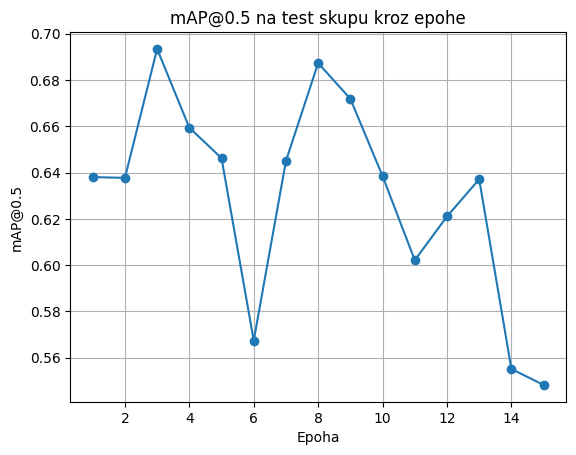

In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import shutil
import os

# Konfiguracija
DATA_YAML_PATH = "yolo_dataset/data.yaml"
BEST_MODEL_PATH = "best_yolov8.pt"
INITIAL_WEIGHTS = "yolov8s.pt"
EPOCHS = 15

# Inicijaliziraj model
model = YOLO(INITIAL_WEIGHTS)
map_scores = []
best_map = 0.0

# Loop po epohama
for epoch in range(EPOCHS):
    print(f"\n Epoha {epoch + 1}/{EPOCHS}")

    # Treniraj samo 1 epohu
    model.train(data=DATA_YAML_PATH, epochs=1, batch=8, imgsz=640, project="runs", name="custom_loop", verbose=True, exist_ok=True)

    # Validacija na test skupu
    metrics = model.val(data=DATA_YAML_PATH, split="test", imgsz=640, batch=8)

    # Dohvati mAP@0.5 i dodaj u listu
    map_50 = metrics.box.map50  # float
    print(f"mAP@0.5 test: {map_50:.4f}")
    map_scores.append(map_50)


# Plotanje rezultata
plt.plot(range(1, EPOCHS + 1), map_scores, marker='o')
plt.title("mAP@0.5 na test skupu kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("mAP@0.5")
plt.grid(True)
plt.show()


!cp -r runs/custom_loop /content/drive/MyDrive/yolov8_split/